# 12. Figures and Tables for Paper

This notebook generates manuscript-ready figures and summary tables from saved artifacts only. The notebook should never depend on training-time variables. Instead, it reuses the canonical outputs created by the earlier notebooks and converts them into publication-ready graphics and tables.


In [1]:
!pip -q install anndata scanpy scikit-learn scipy pandas numpy torch pyarrow

from google.colab import drive
drive.mount('/content/drive')

import os
import sys
import urllib.request
from pathlib import Path

HELPER_DIR = Path("/content/drive/MyDrive/ChemDFM")
if str(HELPER_DIR) not in sys.path:
    sys.path.append(str(HELPER_DIR))

from chemdfm_notebook_helpers import *

DATA_PATH = Path("/content/drive/MyDrive/ChemDFM/data/raw/sciplex_complete_middle_subset.h5ad")
DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    print("Downloading SciPlex dataset...")
    URL = "https://f003.backblazeb2.com/file/chemCPA-datasets/sciplex_complete_middle_subset.h5ad"
    urllib.request.urlretrieve(URL, DATA_PATH)
    print("Download complete.")

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_PATH =", DATA_PATH)
print("Using device:", DEVICE)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 55.4 MB/s eta 0:00:00
Mounted at /content/drive
PROJECT_ROOT = /content/drive/MyDrive/ChemDFM
DATA_PATH = /content/drive/MyDrive/ChemDFM/data/raw/sciplex_complete_middle_subset.h5ad
Using device: cpu


In [2]:
from pathlib import Path
import json, os, random, pickle, warnings
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path("/content/drive/MyDrive/ChemDFM")
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
EXTERNAL_DIR = DATA_DIR / "external"
RUNS_DIR = PROJECT_ROOT / "runs"
RESULTS_DIR = PROJECT_ROOT / "results"
REPORTS_DIR = PROJECT_ROOT / "reports"

for p in [DATA_DIR, RAW_DIR, INTERIM_DIR, PROCESSED_DIR, EXTERNAL_DIR, RUNS_DIR, RESULTS_DIR, REPORTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DEFAULT_H5AD = RAW_DIR / "sciplex_complete_middle_subset.h5ad"

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

def map_split(x: str) -> str:
    x = str(x).lower()
    if "train" in x:
        return "train"
    if "test" in x or "val" in x:
        return "test"
    if "ood" in x:
        return "ood"
    return "drop"

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DEFAULT_H5AD =", DEFAULT_H5AD)


PROJECT_ROOT = /content/drive/MyDrive/ChemDFM
DEFAULT_H5AD = /content/drive/MyDrive/ChemDFM/data/raw/sciplex_complete_middle_subset.h5ad


In [3]:
import matplotlib.pyplot as plt

FIG_DIR = REPORTS_DIR / "figures"
TAB_DIR = REPORTS_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

baseline_path = RESULTS_DIR / "canonical" / "baseline_metrics_overall.csv"
posthoc_path = RESULTS_DIR / "canonical" / "final_overall_metrics_posthoc.csv"
deg_path = RESULTS_DIR / "canonical" / "deg_auprc_summary.csv"
pathway_path = RESULTS_DIR / "canonical" / "pathway_recovery_summary.csv"
dose_path = RESULTS_DIR / "canonical" / "dose_trend_summary.csv"

print("baseline_path exists:", baseline_path.exists())
print("posthoc_path exists:", posthoc_path.exists())


baseline_path exists: True
posthoc_path exists: True


In [4]:
if baseline_path.exists() and posthoc_path.exists():
    baseline_df = pd.read_csv(baseline_path)
    model_df = pd.read_csv(posthoc_path).copy()
    model_df["mode"] = "ResidualDoseResponseModel_CellAwareMMD"
    main_table = pd.concat([
        baseline_df[["split", "mode", "r2_top50", "r2_full", "mse"]],
        model_df.rename(columns={"model": "mode"})[["split", "mode", "r2_top50", "r2_full", "mse"]],
    ], ignore_index=True)
    main_table.to_csv(TAB_DIR / "Table_main_results.csv", index=False)
    display(main_table)


,split,mode,r2_top50,r2_full,mse
0,test,control_copy,0.542528,0.600740,0.374277
1,test,global_mean,0.544917,0.602405,0.372716
2,test,cell_mean,0.547430,0.603489,0.371700
3,test,drug_lookup,0.557363,0.617675,0.358401
4,ood,control_copy,0.503718,0.554779,0.414899
5,ood,global_mean,0.509394,0.559701,0.410312
6,ood,cell_mean,0.514799,0.563591,0.406687
7,ood,drug_lookup,0.520211,0.571480,0.399335
8,test,ResidualDoseResponseModel_CellAwareMMD,0.575433,0.635105,0.342062
9,ood,ResidualDoseResponseModel_CellAwareMMD,0.558478,0.615376,0.358428


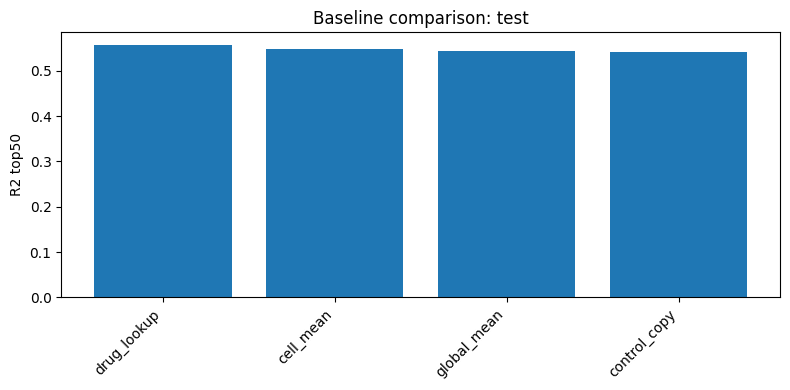

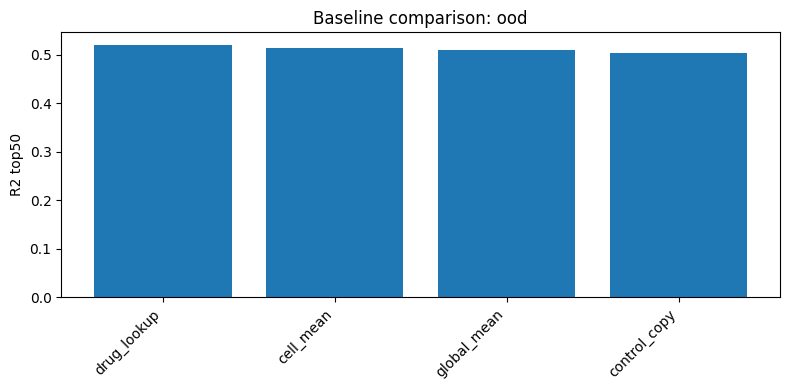

In [5]:
if baseline_path.exists():
    baseline_df = pd.read_csv(baseline_path)
    for split_name in baseline_df["split"].unique():
        sub = baseline_df[baseline_df["split"] == split_name].sort_values("r2_top50", ascending=False)
        plt.figure(figsize=(8, 4))
        plt.bar(sub["mode"], sub["r2_top50"])
        plt.title(f"Baseline comparison: {split_name}")
        plt.ylabel("R2 top50")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"baseline_comparison_{split_name}.png", dpi=200)
        plt.show()


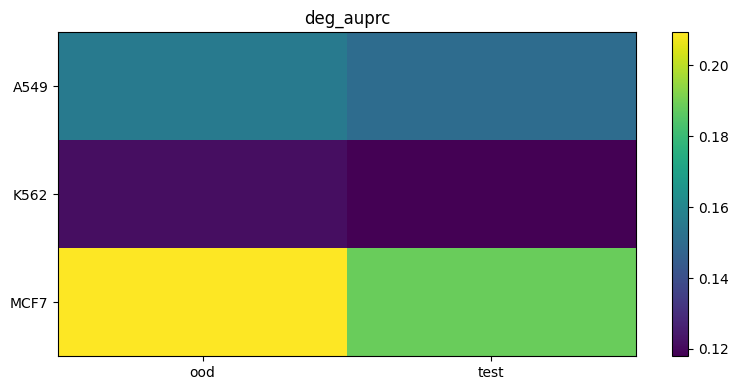

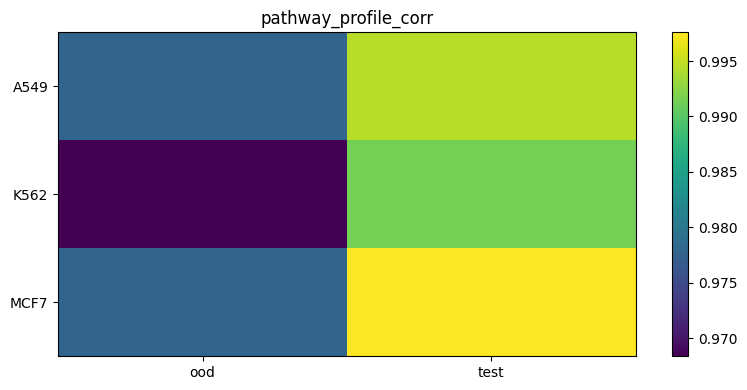

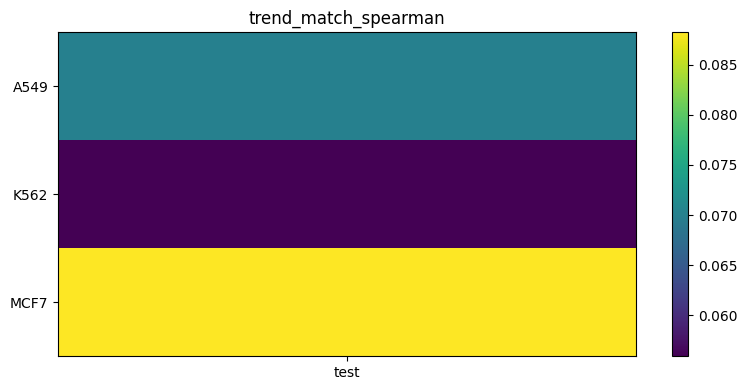

In [6]:
for path, metric in [
    (deg_path, "deg_auprc"),
    (pathway_path, "pathway_profile_corr"),
    (dose_path, "trend_match_spearman"),
]:
    if Path(path).exists():
        df = pd.read_csv(path)
        plt.figure(figsize=(8, 4))
        pivot = df.pivot(index="cell_type", columns="split", values=metric)
        plt.imshow(pivot.values, aspect="auto")
        plt.yticks(range(len(pivot.index)), pivot.index)
        plt.xticks(range(len(pivot.columns)), pivot.columns)
        plt.title(metric)
        plt.colorbar()
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"{metric}_heatmap.png", dpi=200)
        plt.show()


At minimum, the paper directory should contain a main results table, per-cell heatmaps, and separate figures for DEG recovery, pathway-profile recovery, and dose-trend agreement. Additional figures for ablations, cross-split robustness, and confidence intervals can be added once those upstream notebooks have generated the required CSV files.
